# Barcelona Accidents + Weather — SPARQL Pattern-Matching Pipeline

**KG Exploitation Zone · University Final Project**

This notebook documents and **executes live** a SPARQL pattern-matching pipeline over a
knowledge graph (KG) built from Barcelona's traffic-accident records and meteorological
station readings.

## Objective

The *exploitation zone* takes the relational source data — already converted into a
**knowledge graph** in a previous stage — and runs **graph pattern-matching (SPARQL)
analytics** to:

1. **Detect possible accident-fraud / data-quality anomalies** by matching suspicious
   graph *motifs* (duplicate co-located reports, recurring demographic profiles,
   severity-vs-injury inconsistencies).
2. **Answer abstract, multi-hop research questions** that are awkward on flat tables but
   natural on a graph (street hotspots, severity by district and hour, vulnerable-user
   exposure, and a cross-subgraph weather/accident bridge).

Seven analytical questions (Q1–Q7) are posed. For each we state the **goal** (fraud signal
vs. research question), show the **SPARQL motif**, **execute it live** against the
in-memory graph, **visualise** the result (node-link subgraphs for the structural
fraud queries; charts for the analytics queries), and **interpret** the outcome.


## 1. Knowledge graph overview

The KG was authored in **WebProtégé**, so every schema term is an *opaque* IRI under the
namespace `wp: <http://webprotege.stanford.edu/>` (e.g. the class *Accidente* is
`wp:RDHGr7pl4B25glJmq2xYYmN`). A companion config module
(`config/ontology.py`) maps every opaque IRI back to a **readable name**, so neither this
notebook nor the queries hard-code raw `R...` strings beyond the `.rq` files.

### Two disconnected subgraphs

The ABOX (instances) is made of **two connected components that share no edge**:

| Subgraph | Shape | Key data properties |
|----------|-------|---------------------|
| **Accidents** | `Persona —InvolucradoEn→ Accidente —UbicadoEn→ Lugar` | `Accidente`: `FechadoEn`, `NumFeritLleu/Greu`, `NumMort`, `AccidentID`; `Lugar`: `Distrito/Barrio/Calle`; `Persona`: `Edad/Sexo/VehicleImplicat` |
| **Weather** | `EstacionMeteorologica —Medir→ LecturaMeteorologica` | `Valor`, `Acronimo` (15 measure codes), `FechadoEn` |

`Accidente` has four subtypes: **Leve / Grave / Mortal / SinVictima**.
There are **3 weather stations** (D5, X4, X8).

> **The two subgraphs meet only on the date** (`FechadoEn`): there is *no* edge linking a
> station/reading to any accident or place. This single fact drives the entire Q7 design
> (it is split into two single-subgraph aggregations joined on the date in pandas — see §3
> and the technical report).

### Instance counts (from EDA)

| Entity | Count | Breakdown |
|--------|-------|-----------|
| `Accidente` | **7,741** | Leve 6,599 · SinVictima 890 · Grave 241 · **Mortal 11** |
| `Persona` | **16,001** | Conductor 14,126 · Passatger 2,009 · Vianant 1,065 |
| `Lugar` | **4,386** | distrito / barrio / calle |
| `EstacionMeteorologica` | **3** | D5, X4, X8 |
| `LecturaMeteorologica` | **~16,000** | 15 daily measures, full-year 2025 |
| **Total triples** | **≈ 257,593** | |

The TTL is **self-contained**: it embeds the TBOX (including `rdfs:label`s), so
class-label lookups (used by Q3/Q5/Q6) work while loading **only** the TTL.


### Schematic of the TBOX-level shape

The cell below draws the *schema* (class-level) shape of both subgraphs and their
disconnect — not the 257k-triple instance graph, just the motif every query walks.

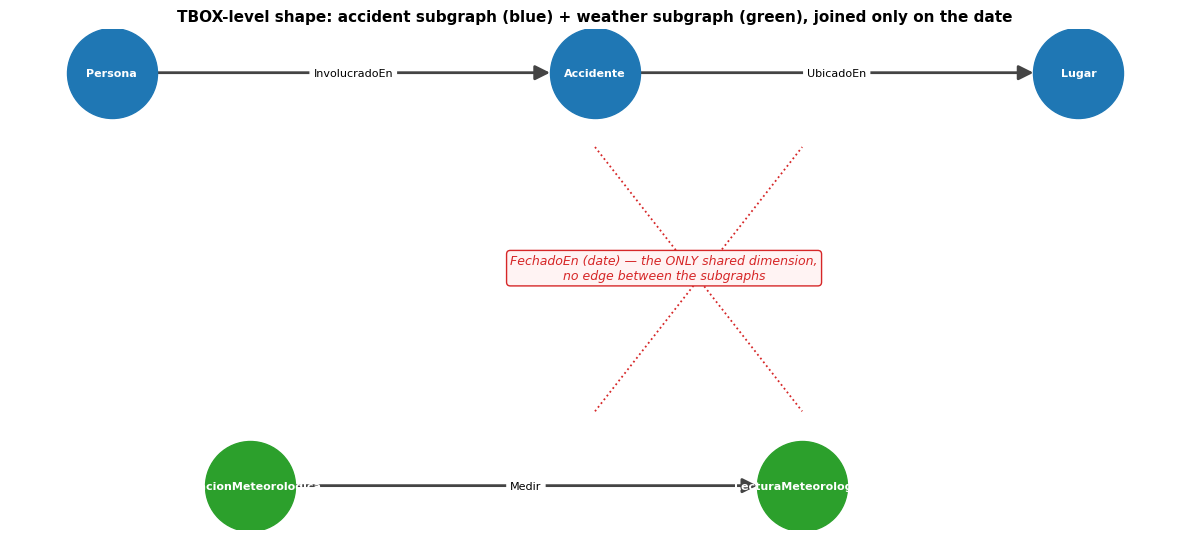

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(12, 5.5))
G = nx.DiGraph()
# accident subgraph
G.add_edge("Persona", "Accidente", label="InvolucradoEn")
G.add_edge("Accidente", "Lugar", label="UbicadoEn")
# weather subgraph
G.add_edge("EstacionMeteorologica", "LecturaMeteorologica", label="Medir")

pos = {
    "Persona": (0.0, 1.0), "Accidente": (1.4, 1.0), "Lugar": (2.8, 1.0),
    "EstacionMeteorologica": (0.4, 0.0), "LecturaMeteorologica": (2.0, 0.0),
}
acc_nodes = ["Persona", "Accidente", "Lugar"]
wx_nodes = ["EstacionMeteorologica", "LecturaMeteorologica"]
nx.draw_networkx_nodes(G, pos, nodelist=acc_nodes, node_color="#1f77b4",
                       node_size=4200, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=wx_nodes, node_color="#2ca02c",
                       node_size=4200, ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=22, width=2,
                       node_size=4200, edge_color="#444")
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white",
                        font_weight="bold", ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"),
                             font_size=8, ax=ax)
# the shared-but-unlinked time dimension
ax.annotate("FechadoEn (date) — the ONLY shared dimension,\nno edge between the subgraphs",
            xy=(1.6, 0.5), ha="center", fontsize=9, style="italic", color="#d62728",
            bbox=dict(boxstyle="round", fc="#fff3f3", ec="#d62728"))
ax.plot([1.4, 2.0], [0.82, 0.18], ls=":", color="#d62728", lw=1.3)
ax.plot([1.4, 2.0], [0.18, 0.82], ls=":", color="#d62728", lw=1.3)
ax.set_title("TBOX-level shape: accident subgraph (blue) + weather subgraph (green), "
             "joined only on the date", fontsize=11, fontweight="bold")
ax.axis("off"); plt.tight_layout(); plt.show()

## 2. Setup

We add the exploitation-zone directory to `sys.path` and import the shared
`config.ontology` module (readable→IRI maps, `PREFIXES`, `TTL_FILE`, `MEASURE_CODES`).
Then we define a `run_query(name)` helper that reads a `.rq` file and runs it on the
**once-loaded** graph, returning a pandas `DataFrame`.

In [2]:
import sys, time
from pathlib import Path
import pandas as pd
import rdflib

ZONE_DIR = Path(r"C:\UPC\BCN-Meteorologics\KG_exploit_zone")
sys.path.insert(0, str(ZONE_DIR))
from config import ontology as O   # readable->IRI maps, PREFIXES, TTL_FILE, MEASURE_CODES

QUERIES_DIR = ZONE_DIR / "sparql_pipeline" / "queries"
print("rdflib", rdflib.__version__, "| pandas", pd.__version__)
print("TTL:", O.TTL_FILE.name, "| queries dir:", QUERIES_DIR.relative_to(ZONE_DIR))

rdflib 7.6.0 | pandas 2.3.3
TTL: kg_accidentes_bcn.ttl | queries dir: sparql_pipeline\queries


### Load the graph **once** (~6–16 s)

Loading the 257k-triple TTL is the only slow step. We do it **a single time** and reuse
the same `rdflib.Graph` for every query — re-parsing per query would be wasteful, and a
flat accident×reading cross-product would *hang* rdflib (avoided by design; see the
technical report).

In [3]:
g = rdflib.Graph()
_t0 = time.time()
g.parse(str(O.TTL_FILE), format="turtle")
PARSE_SECONDS = time.time() - _t0
print(f"Loaded {len(g):,} triples in {PARSE_SECONDS:.1f}s")

Loaded 257,593 triples in 10.1s


### The `run_query` helper

Backend selection mirrors the production runner `run_sparql.py`: **GraphDB is the
recommended backend** (scalable HTTP SPARQL endpoint), with an **rdflib in-memory
fallback** that needs no server. We probe for a running GraphDB; if absent we use the
already-loaded rdflib graph. Either way `run_query` returns a tidy `DataFrame` and records
the per-query wall-clock time in `QUERY_TIMES`.

In [4]:
import urllib.request

def graphdb_available() -> bool:
    try:
        with urllib.request.urlopen(O.GRAPHDB_BASE + "/rest/repositories", timeout=2) as r:
            return r.status == 200
    except Exception:
        return False

BACKEND = "graphdb" if graphdb_available() else "rdflib"
print(f"Auto-selected backend: {BACKEND}"
      + ("" if BACKEND == "graphdb" else "  (no GraphDB server detected -> in-memory rdflib)"))

QUERY_TIMES = {}

def read_query(name: str) -> str:
    'Return the raw SPARQL text of queries/<name>.rq.'
    return (QUERIES_DIR / f"{name}.rq").read_text(encoding="utf-8")

def run_query(name: str) -> pd.DataFrame:
    'Read queries/<name>.rq, run it on the once-loaded graph, return a DataFrame.'
    text = read_query(name)
    t0 = time.time()
    if BACKEND == "graphdb":
        from SPARQLWrapper import CSV, SPARQLWrapper
        import csv, io
        sw = SPARQLWrapper(O.GRAPHDB_QUERY_ENDPOINT)
        sw.setQuery(text); sw.setReturnFormat(CSV)
        raw = sw.query().convert()
        txt = raw.decode("utf-8") if isinstance(raw, (bytes, bytearray)) else str(raw)
        df = pd.read_csv(io.StringIO(txt))
    else:
        res = g.query(text)
        cols = [str(v) for v in res.vars]
        rows = [["" if v is None else str(v) for v in row] for row in res]
        df = pd.DataFrame(rows, columns=cols)
    QUERY_TIMES[name] = time.time() - t0
    return df

def show_sparql(name: str) -> None:
    'Pretty-print the SPARQL text of a query for the report.'
    print(read_query(name))

Auto-selected backend: rdflib  (no GraphDB server detected -> in-memory rdflib)


A small helper coerces the string columns rdflib returns into numeric dtypes for
plotting and aggregation.

In [5]:
def numify(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def short(uri: str) -> str:
    s = str(uri)
    return s.rsplit("/", 1)[-1] if "/" in s else s

## Q1 — Duplicate / co-located reports

**Goal — FRAUD signal.** *Are there distinct accident expedients registered at the exact
same place **and** the same timestamp?* Two separate accident files for one place+instant
is a classic **duplicate-claim** red flag.

**Graph motif.** A `Lugar`+`FechadoEn` pair acts as a **hub**; we look for hubs reached by
**more than one** distinct `Accidente` (each carrying its own `AccidentID`). A graph model
makes this a pure structural query — group by the shared `(place, instant)` and count the
incident accidents — no manual key engineering.

In [6]:
show_sparql('Q1_duplicate_reports')

# Q1 — Duplicate / co-located reports (FRAUD signal)
# Distinct accident expedients registered at the SAME place AND the same timestamp.
# Two separate accident files for one place+instant is a classic duplicate-claim red flag.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?lugar ?fecha (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (GROUP_CONCAT(DISTINCT ?id; SEPARATOR=", ") AS ?expedientes)
WHERE {
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar ;     # UbicadoEn
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?fecha ;     # FechadoEn
       wp:RiUMyEG1nwNphv16JMNmsZ ?id .         # AccidentID
}
GROUP BY ?lugar ?fecha
HAVING (COUNT(DISTINCT ?acc) > 1)
ORDER BY DESC(?numAccidentes)



In [7]:
q1 = run_query("Q1_duplicate_reports")
q1 = numify(q1, ["numAccidentes"])
print(f"{len(q1)} place+instant collisions  ({QUERY_TIMES['Q1_duplicate_reports']:.2f}s)")
q1.head(10)

19 place+instant collisions  (1.25s)


,lugar,fecha,numAccidentes,expedientes
0,http://data.bcn.cat/accidentes/lloc/240707_0,2025-06-09T08:00:00,2,"2025S003311, 2025S003374"
1,http://data.bcn.cat/accidentes/lloc/18505_Desc...,2025-07-24T14:00:00,2,"2025S004441, 2025S004442"
2,http://data.bcn.cat/accidentes/lloc/169409_Des...,2025-09-03T17:00:00,2,"2025S005192, 2025S005148"
3,http://data.bcn.cat/accidentes/lloc/350308_Des...,2025-09-11T21:00:00,2,"2025S005340, 2025S005341"
4,http://data.bcn.cat/accidentes/lloc/350308_662...,2025-09-14T00:00:00,2,"2025S005369, 2025S005472"
5,http://data.bcn.cat/accidentes/lloc/297001_Des...,2025-09-18T11:00:00,2,"2025S005455, 2025S005459"
6,http://data.bcn.cat/accidentes/lloc/350308_Des...,2025-11-26T17:00:00,2,"2025S007024, 2025S007026"
7,http://data.bcn.cat/accidentes/lloc/169409_Des...,2025-12-15T06:00:00,2,"2025S007427, 2025S007423"
8,http://data.bcn.cat/accidentes/lloc/18505_283-285,2025-03-01T14:00:00,2,"2025S001158, 2025S001157"
9,http://data.bcn.cat/accidentes/lloc/76807_Desc...,2025-03-28T19:00:00,2,"2025S001727, 2025S001743"


**Visualization — node-link subgraph.** Each red square is a `Lugar+Fecha` hub; blue nodes are the colliding accident expedients linked to it (the actual matched motif).

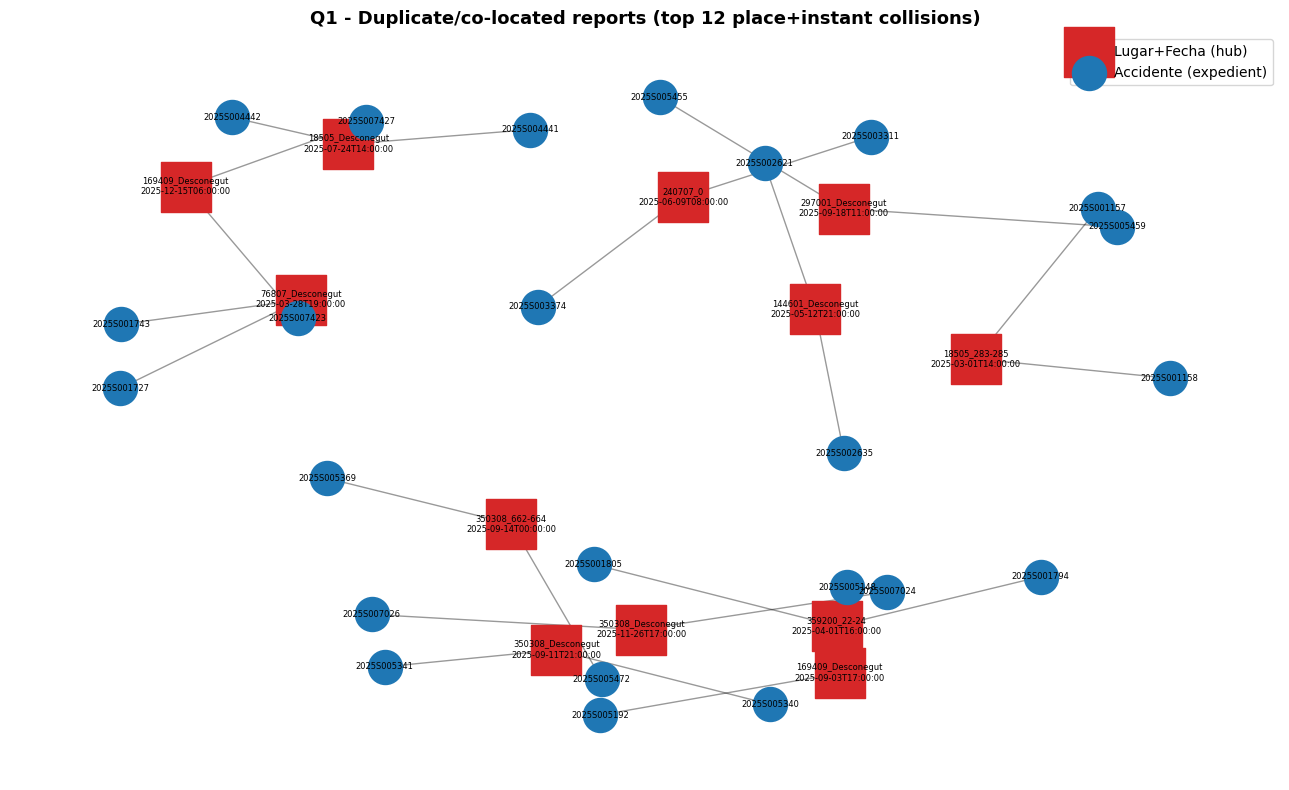

In [8]:
df = q1.sort_values("numAccidentes", ascending=False).head(12)
Gv = nx.Graph(); place_nodes, acc_nodes = [], []
for _, r in df.iterrows():
    hub = f"{short(r['lugar'])}\n{r['fecha']}"; place_nodes.append(hub)
    for exp in str(r["expedientes"]).split(", "):
        Gv.add_edge(hub, exp); acc_nodes.append(exp)
fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(Gv, k=0.6, seed=42)
nx.draw_networkx_edges(Gv, pos, ax=ax, alpha=0.4)
nx.draw_networkx_nodes(Gv, pos, nodelist=place_nodes, node_color="#d62728",
                       node_shape="s", node_size=1300, ax=ax, label="Lugar+Fecha (hub)")
nx.draw_networkx_nodes(Gv, pos, nodelist=acc_nodes, node_color="#1f77b4",
                       node_size=600, ax=ax, label="Accidente (expedient)")
nx.draw_networkx_labels(Gv, pos, font_size=6, ax=ax)
ax.legend(scatterpoints=1, loc="upper right"); ax.axis("off")
ax.set_title(f"Q1 - Duplicate/co-located reports (top {len(df)} place+instant collisions)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** Q1 finds **19** place+instant collisions — pairs (and a few
larger groups) of distinct expedients sharing one `Lugar` and the very same `FechadoEn`.
Most are clean pairs of consecutive expedient numbers (e.g. `...4441 / ...4442`), which
typically means one physical event split into two administrative files rather than outright
fraud — but they are exactly the candidates an auditor should review first. The motif is
the value here: on a flat table this needs an explicit self-join on `(place_id, timestamp)`;
on the graph it is a single group-by over a shared hub.

## Q2 — Recurring demographic profile at the same place

**Goal — FRAUD signal.** *Does the same demographic profile (age + sex + vehicle) appear in
**multiple** distinct accidents at the **same** place?* The graph has no person-identity
key, so we **fingerprint** people by `(Edad, Sexo, VehicleImplicat)`. A recurring identical
fingerprint clustered at one spot can indicate a **staged-claim ring**.

**Graph motif.** `Persona —InvolucradoEn→ Accidente —UbicadoEn→ Lugar`, grouped by
`(Lugar, Edad, Sexo, Vehiculo)`, keeping groups that span `>1` accident. This is a genuine
multi-hop co-participation pattern — implicit in the graph (people share an `Accidente`
node) but needing explicit join keys in SQL.

In [9]:
show_sparql('Q2_repeat_coparticipation')

# Q2 — Repeated demographic profile across accidents at the same place (FRAUD signal)
# Persons sharing the SAME age + sex + vehicle that appear in >1 distinct accident
# located at the SAME place. A recurring identical profile at one spot can indicate a
# staged-claim ring (the graph has no person-identity key, so we fingerprint by profile).
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?lugar ?edad ?sexo ?vehiculo
       (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (GROUP_CONCAT(DISTINCT ?accId; SEPARATOR=", ") AS ?expedientes)
WHERE {
  ?persona wp:Rqp27L1N9oTZweWd4AbJKw ?acc ;    # InvolucradoEn
           wp:RCsWF1rtGUwHlrCw2nFCiyE ?edad ;   # Edad
           wp:RDEVg1ttXmeqGODajUtvvgq ?sexo ;   # Sexo
           wp:R94iV1JYRs5IqQSGPTpJbM8 ?vehiculo . # VehicleImplicat
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar ;
       wp:RiUMyEG1nwNphv16JMNmsZ ?accId .
}
GROUP BY ?lugar ?edad ?sexo ?vehiculo
HAVING (COUNT(DISTINCT ?acc) > 1)
ORDER BY DESC(?numAccidentes)
LIMIT 200



In [10]:
q2 = run_query("Q2_repeat_coparticipation")
q2 = numify(q2, ["edad", "numAccidentes"])
print(f"{len(q2)} recurring profile@place groups  ({QUERY_TIMES['Q2_repeat_coparticipation']:.2f}s)")
q2.head(10)

200 recurring profile@place groups  (2.89s)


,lugar,edad,sexo,vehiculo,numAccidentes,expedientes
0,http://data.bcn.cat/accidentes/lloc/169409_Des...,55,H,Turisme,7,"2025S000060, 2025S000346, 2025S000760, 2025S00..."
1,http://data.bcn.cat/accidentes/lloc/169409_Des...,31,H,Turisme,7,"2025S000618, 2025S003262, 2025S004592, 2025S00..."
2,http://data.bcn.cat/accidentes/lloc/169409_Des...,28,H,Motocicleta,7,"2025S001296, 2025S003023, 2025S003523, 2025S00..."
3,http://data.bcn.cat/accidentes/lloc/144601_Des...,23,H,Motocicleta,5,"2025S000027, 2025S001419, 2025S002519, 2025S00..."
4,http://data.bcn.cat/accidentes/lloc/18505_Desc...,40,H,Motocicleta,5,"2025S000212, 2025S002573, 2025S003627, 2025S00..."
5,http://data.bcn.cat/accidentes/lloc/144601_Des...,28,H,Motocicleta,5,"2025S000318, 2025S000839, 2025S004454, 2025S00..."
6,http://data.bcn.cat/accidentes/lloc/18505_Desc...,41,H,Turisme,5,"2025S000486, 2025S002040, 2025S004506, 2025S00..."
7,http://data.bcn.cat/accidentes/lloc/144601_Des...,48,H,Turisme,5,"2025S000682, 2025S001135, 2025S004149, 2025S00..."
8,http://data.bcn.cat/accidentes/lloc/169409_Des...,36,H,Turisme,5,"2025S001616, 2025S002225, 2025S004214, 2025S00..."
9,http://data.bcn.cat/accidentes/lloc/144601_Des...,29,H,Motocicleta,5,"2025S002991, 2025S004717, 2025S005521, 2025S00..."


**Visualization — node-link subgraph.** Purple squares are `place + (age/sex/vehicle)` profile hubs; green nodes are the accidents that profile recurs in.

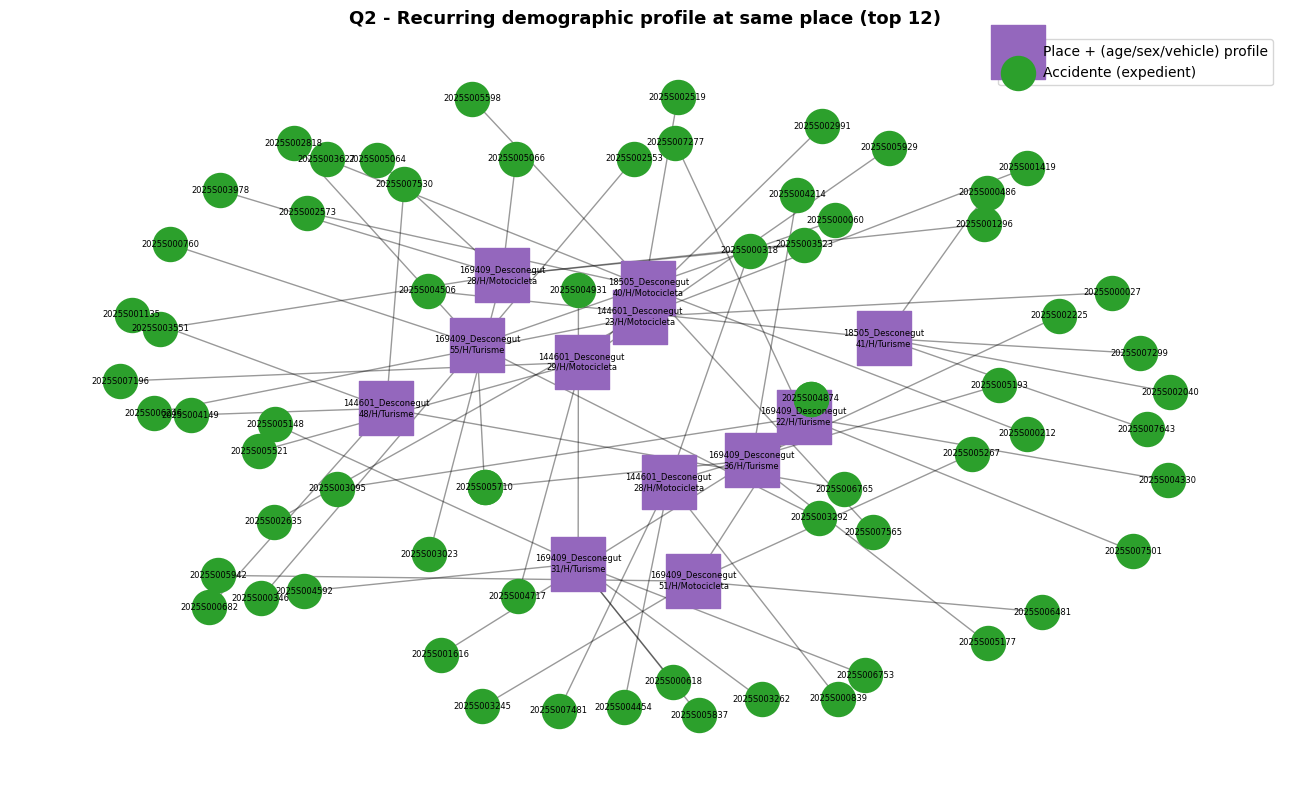

In [11]:
df = q2.sort_values("numAccidentes", ascending=False).head(12)
Gv = nx.Graph(); hubs, accs = [], []
for _, r in df.iterrows():
    hub = f"{short(r['lugar'])}\n{r['edad']}/{r['sexo']}/{r['vehiculo']}"; hubs.append(hub)
    for exp in str(r["expedientes"]).split(", "):
        Gv.add_edge(hub, exp); accs.append(exp)
fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(Gv, k=0.7, seed=42)
nx.draw_networkx_edges(Gv, pos, ax=ax, alpha=0.4)
nx.draw_networkx_nodes(Gv, pos, nodelist=hubs, node_color="#9467bd", node_shape="s",
                       node_size=1500, ax=ax, label="Place + (age/sex/vehicle) profile")
nx.draw_networkx_nodes(Gv, pos, nodelist=accs, node_color="#2ca02c",
                       node_size=600, ax=ax, label="Accidente (expedient)")
nx.draw_networkx_labels(Gv, pos, font_size=6, ax=ax)
ax.legend(scatterpoints=1, loc="upper right"); ax.axis("off")
ax.set_title(f"Q2 - Recurring demographic profile at same place (top {len(df)})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** Q2 returns the full **200**-row cap of recurring profiles. The
strongest hits concentrate at place `169409_Desconegut`, where profiles such as
**55 / H / Turisme** and **31 / H / Turisme** each recur across **7** distinct accidents.
A profile fingerprint is *not* proof of fraud — common profiles (middle-aged male car
driver) recur naturally, and `Desconegut` ("unknown") places aggregate many records — but
the densest profile@place clusters are precisely the leads a staged-claim investigation
would prioritise. The subgraph makes the fan-out (one fingerprint → many accidents)
immediately visible.

## Q3 — Severity label vs. injury-count inconsistency

**Goal — FRAUD / data-quality signal.** *Is any accident's **severity class** contradicted
by its **recorded injury counts**?* Specifically: typed **Mortal** but `NumMort = 0`; typed
**Grave** but `NumFeritGreu = 0`; or typed **SinVictima** but with a positive victim count.
Such label/measure mismatches are either data errors or manipulated reports.

**Graph motif.** `Accidente —rdf:type→ class —rdfs:label→ ?tipo`, joined to the three
injury-count data properties, filtered to the contradiction predicate. Note this query
**reads class labels from the TBOX embedded in the TTL** — possible only because the TTL is
self-contained.

In [12]:
show_sparql('Q3_severity_inconsistency')

# Q3 — Severity vs. injury-count inconsistency (FRAUD / data-quality signal)
# An accident typed as Grave or Mortal but whose recorded greu+mort counts are both 0,
# OR typed SinVictima but carrying a positive leve count. Such label/measure mismatches
# are either data errors or manipulated reports.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?acc ?id ?tipo ?lleu ?greu ?mort
WHERE {
  ?acc a ?clase ;
       wp:RiUMyEG1nwNphv16JMNmsZ ?id .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)   # skip the abstract superclass label

  OPTIONAL { ?acc wp:R8RNUHdxy4iNBMh6DiKMNHR ?lleu }   # NumFeritLleu
  OPTIONAL { ?acc wp:R9KzZ5w47b2GzTS1wFlEzB6 ?greu }   # NumFeritGreu
  OPTIONAL { ?acc wp:RDLF2iVJgjiRFE4TYcqZ6a3 ?mort }   # NumMort

  BIND(COALESCE(?lleu,0) AS ?nl)
  BIND(COALESCE(?greu,0) AS ?ng)
  BIND(COALESCE(?mort,0) AS ?nm)

  FILTER(
    (?

In [13]:
q3 = run_query("Q3_severity_inconsistency")
print(f"{len(q3)} inconsistent accidents  ({QUERY_TIMES['Q3_severity_inconsistency']:.2f}s)")
q3.head(10)

0 inconsistent accidents  (5.42s)


,acc,id,tipo,lleu,greu,mort


**Visualization.** Q3 returns **0 rows**, so there is no subgraph to draw. We present
the result honestly as a clean-data outcome and illustrate the *inconsistency motif* the
query searches for (an accident node whose type label contradicts its injury counts).

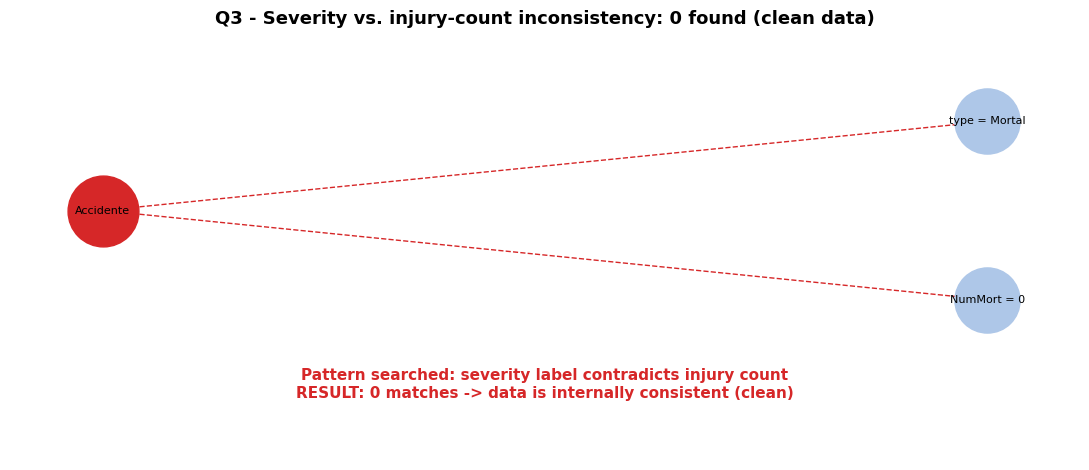

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.8))
if len(q3) == 0:
    # draw the (hypothetical) motif the query hunts for, marked as NOT FOUND
    Gd = nx.Graph()
    Gd.add_edge("Accidente", "type = Mortal")
    Gd.add_edge("Accidente", "NumMort = 0")
    pos = {"Accidente": (0, 0), "type = Mortal": (1, 0.5), "NumMort = 0": (1, -0.5)}
    nx.draw_networkx_edges(Gd, pos, ax=ax, style="dashed", edge_color="#d62728")
    nx.draw_networkx_nodes(Gd, pos, nodelist=["Accidente"], node_color="#d62728",
                           node_size=2600, ax=ax)
    nx.draw_networkx_nodes(Gd, pos, nodelist=["type = Mortal", "NumMort = 0"],
                           node_color="#aec7e8", node_size=2200, ax=ax)
    nx.draw_networkx_labels(Gd, pos, font_size=8, ax=ax)
    ax.text(0.5, -1.05, "Pattern searched: severity label contradicts injury count\n"
            "RESULT: 0 matches -> data is internally consistent (clean)",
            ha="center", fontsize=11, color="#d62728", fontweight="bold",
            transform=ax.transData)
    ax.set_ylim(-1.4, 1.0); ax.axis("off")
    ax.set_title("Q3 - Severity vs. injury-count inconsistency: 0 found (clean data)",
                 fontsize=13, fontweight="bold")
else:
    counts = q3["tipo"].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color="#ff7f0e")
    ax.set_xlabel("inconsistent accidents")
    ax.set_title(f"Q3 - inconsistencies by severity type ({len(q3)} total)",
                 fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** Q3 returns **0 rows** — and that is a **valid, positive result**:
across all 7,741 accidents, **no** severity label contradicts its injury counts. Every
*Mortal* records ≥1 death, every *Grave* ≥1 serious injury, and no *SinVictima* carries
victims. The dataset is **internally consistent** on this integrity rule. Reporting a clean
negative is as important as reporting hits: it tells an auditor this particular
manipulation vector is not present.

## Q4 — Accident hotspots

**Goal — RESEARCH question (analytics).** *Which streets accumulate the most accidents and
the most victims?* Multi-hop aggregation `Accidente —UbicadoEn→ Lugar(calle, barrio,
distrito)`, ranked by accident count and stacked victim totals (lleus / greus / morts).

In [15]:
show_sparql('Q4_accident_hotspots')

# Q4 — Accident hotspots (multi-hop analytics)
# Rank streets (within barrio/district) by number of accidents and total victims.
# Multi-hop: Accidente -> Lugar(calle,barrio,distrito), aggregated.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?distrito ?barrio ?calle
       (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (SUM(?nl) AS ?totalLleus) (SUM(?ng) AS ?totalGreus) (SUM(?nm) AS ?totalMorts)
WHERE {
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?lugar wp:R9J0LyEyfULTAx5DDRGG4Ys ?calle .       # Calle
  OPTIONAL { ?lugar wp:RCJq0kcAKOAezhCOBeEqGlT ?barrio }    # Barrio
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }  # Distrito
  OPTIONAL { ?acc wp:R8RNUHdxy4iNBMh6DiKMNHR ?l } BIND(COALESCE(?l,0) AS ?nl)
  OPTIONAL { ?acc wp:R9KzZ5w47b2GzTS1wFlEzB6 ?g } BIND(COALESCE(?g,0) AS ?ng)
  OPTIONAL { ?acc wp:RDLF2iVJgjiRFE4TYcqZ6a3 ?m } BIND(COALESCE(?m,0) AS ?nm)
}
GROUP BY ?distrito ?barrio ?calle
ORDER BY DESC(?numAccidentes)
LIMIT 50



In [16]:
q4 = run_query("Q4_accident_hotspots")
q4 = numify(q4, ["numAccidentes", "totalLleus", "totalGreus", "totalMorts"])
print(f"{len(q4)} street rows  ({QUERY_TIMES['Q4_accident_hotspots']:.2f}s)")
q4.head(10)

50 street rows  (2.91s)


,distrito,barrio,calle,numAccidentes,totalLleus,totalGreus,totalMorts
0,Eixample,la Nova Esquerra de l'Eixample,Corts Catalanes,194,217,9,0
1,Eixample,la Dreta de l'Eixample,Aragó,183,206,3,1
2,Eixample,el Fort Pienc,Diagonal,159,232,12,1
3,Eixample,la Sagrada Família,València,109,111,1,0
4,Sant Andreu,Sant Andreu,Meridiana,86,106,2,1
5,Sants-Montjuïc,el Poble Sec,Paral·lel,55,65,1,0
6,Eixample,la Dreta de l'Eixample,Gràcia,55,70,1,0
7,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,General Mitre,49,53,1,0
8,Eixample,la Dreta de l'Eixample,Balmes,49,60,4,0
9,Les Corts,la Maternitat i Sant Ramon,Diagonal,47,55,2,0


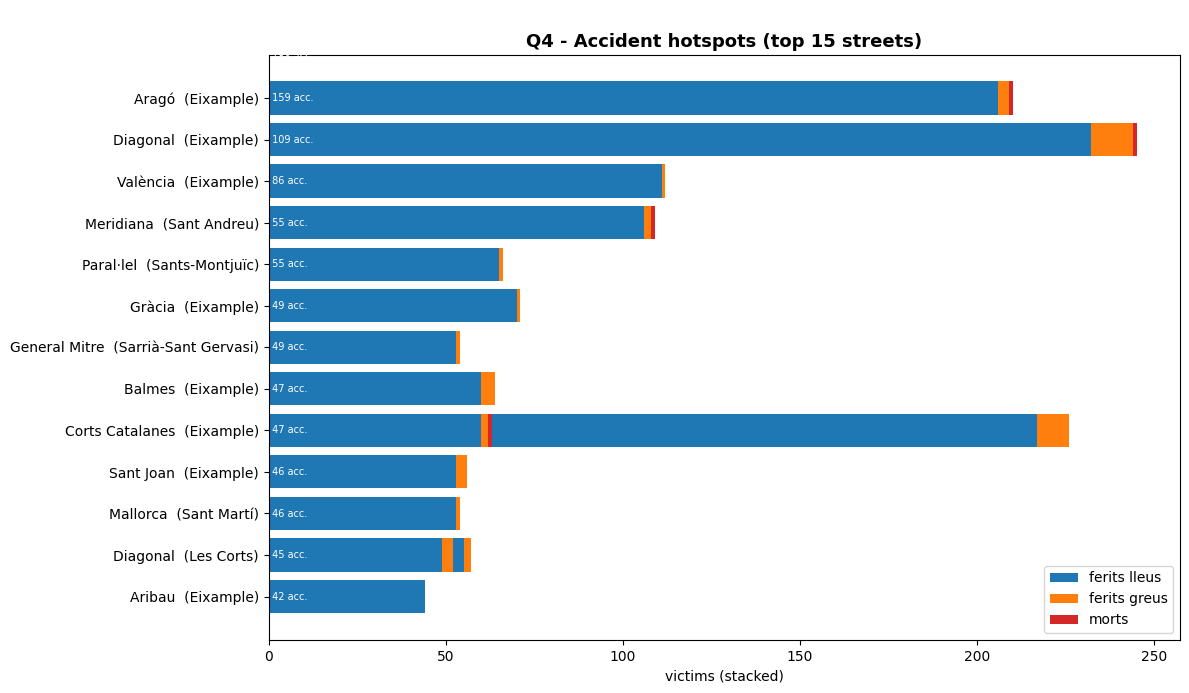

In [17]:
df = q4.sort_values("numAccidentes", ascending=False).head(15).iloc[::-1]
label = df["calle"].fillna("?") + "  (" + df["distrito"].fillna("?") + ")"
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(label, df["totalLleus"], color="#1f77b4", label="ferits lleus")
ax.barh(label, df["totalGreus"], left=df["totalLleus"], color="#ff7f0e", label="ferits greus")
ax.barh(label, df["totalMorts"], left=df["totalLleus"] + df["totalGreus"],
        color="#d62728", label="morts")
for i, n in enumerate(df["numAccidentes"]):
    ax.text(0, i, f" {int(n)} acc.", va="center", ha="left", fontsize=7, color="white")
ax.set_xlabel("victims (stacked)"); ax.legend(loc="lower right")
ax.set_title("Q4 - Accident hotspots (top 15 streets)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** The ranking is dominated by Barcelona's major arteries — **Gran
Via de les Corts Catalanes**, **Av. Diagonal**, **Carrer d'Aragó** — consistent with the
EDA hotspot counts. These are long, high-traffic corridors, so high absolute counts are
expected; the stacked bars add the severity mix (mostly *lleus*, with a thin *greus/morts*
tail) that a raw count alone would hide.

## Q5 — Severity by district and hour of day

**Goal — RESEARCH question (analytics).** *How does accident severity vary by hour of day
(and district)?* The hour is extracted from the `FechadoEn` timestamp with
`SUBSTR(STR(?fecha), 12, 2)` — a **datatype-agnostic** slice that survived the
`xsd:string → xsd:dateTimeStamp` migration (native `HOURS()` casts fail on
`dateTimeStamp` in rdflib; see the technical report).

In [18]:
show_sparql('Q5_severity_by_district_hour')

# Q5 — Severity breakdown by district and hour-of-day (analytics)
# Extracts the hour from the FechadoEn timestamp string ("2025-01-11T03:00:00")
# and counts accidents per district / hour / severity-type.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?distrito ?hora ?tipo (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc a ?clase ;
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?fecha ;       # FechadoEn
       wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }
  # timestamp looks like 2025-01-11T03:00:00 -> hour = chars 12-13
  BIND(SUBSTR(STR(?fecha), 12, 2) AS ?hora)
}
GROUP BY ?distrito ?hora ?tipo
ORDER BY ?distrito ?hora



In [19]:
q5 = run_query("Q5_severity_by_district_hour")
q5 = numify(q5, ["hora", "numAccidentes"])
print(f"{len(q5)} (district,hour,type) rows  ({QUERY_TIMES['Q5_severity_by_district_hour']:.2f}s)")
q5.head(10)

591 (district,hour,type) rows  (2.67s)


,distrito,hora,tipo,numAccidentes
0,Ciutat Vella,0,AccidenteSinVictima,2
1,Ciutat Vella,0,AccidenteLeve,7
2,Ciutat Vella,1,AccidenteSinVictima,8
3,Ciutat Vella,1,AccidenteLeve,9
4,Ciutat Vella,2,AccidenteSinVictima,2
5,Ciutat Vella,2,AccidenteLeve,6
6,Ciutat Vella,3,AccidenteSinVictima,2
7,Ciutat Vella,3,AccidenteLeve,2
8,Ciutat Vella,4,AccidenteSinVictima,5
9,Ciutat Vella,4,AccidenteLeve,5


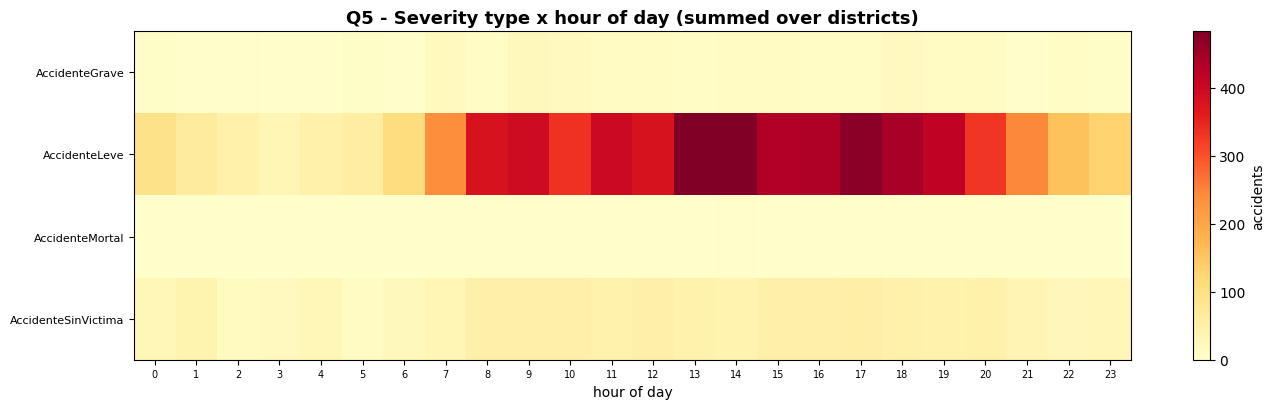

In [20]:
piv = q5.pivot_table(index="tipo", columns="hora", values="numAccidentes",
                     aggfunc="sum", fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4.2))
im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([int(c) for c in piv.columns], fontsize=7)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8)
ax.set_xlabel("hour of day"); fig.colorbar(im, ax=ax, label="accidents")
ax.set_title("Q5 - Severity type x hour of day (summed over districts)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** Accidents concentrate in the **daytime / evening rush
(≈13:00–18:00)** with a clear **night trough (≈02:00–05:00)**, matching the EDA. The
*Leve* row dominates the heatmap; *Grave/Mortal* are too rare (241 / 11 total) to form a
visible band, but the temporal profile is the same shape — exposure tracks traffic volume,
not a particular hour being disproportionately deadly.

## Q6 — Vulnerable-user exposure

**Goal — RESEARCH question (analytics).** *Where are vulnerable road users (pedestrians and
two-wheel / personal-mobility riders) most exposed?* Filters persons with no vehicle
(pedestrian) or a `Bicicleta / Ciclomotor / Motocicleta / mobilitat personal` vehicle,
then aggregates by `(distrito, barrio, severity-type)`.

In [21]:
show_sparql('Q6_vulnerable_users')

# Q6 — Vulnerable road users exposure (analytics)
# Accidents involving pedestrians (Vianant) or two-wheel / personal-mobility riders,
# with their place and the accident severity type. Highlights where vulnerable users
# are most exposed.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?distrito ?barrio ?tipo (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?persona wp:Rqp27L1N9oTZweWd4AbJKw ?acc .       # InvolucradoEn
  OPTIONAL { ?persona wp:R94iV1JYRs5IqQSGPTpJbM8 ?vehiculo }  # VehicleImplicat

  # vulnerable = pedestrian (no vehicle / Vianant typed) OR light two-wheel / VMP
  FILTER( !BOUND(?vehiculo)
          || REGEX(?vehiculo, "Bicicleta|Ciclomotor|Motocicleta|mobilitat personal", "i") )

  ?acc a ?clase ;
       wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }
  OPTIONAL { ?lugar wp:RCJq0kcAKOAezh

In [22]:
q6 = run_query("Q6_vulnerable_users")
q6 = numify(q6, ["numAccidentes"])
print(f"{len(q6)} (district,barrio,type) rows  ({QUERY_TIMES['Q6_vulnerable_users']:.2f}s)")
q6.head(10)

100 (district,barrio,type) rows  (7.03s)


,distrito,barrio,tipo,numAccidentes
0,Eixample,la Dreta de l'Eixample,AccidenteLeve,534
1,Eixample,la Nova Esquerra de l'Eixample,AccidenteLeve,261
2,Eixample,la Sagrada Família,AccidenteLeve,233
3,Eixample,el Fort Pienc,AccidenteLeve,228
4,Eixample,l'Antiga Esquerra de l'Eixample,AccidenteLeve,177
5,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,AccidenteLeve,164
6,Sarrià-Sant Gervasi,Sant Gervasi - la Bonanova,AccidenteLeve,140
7,Les Corts,les Corts,AccidenteLeve,133
8,Sant Andreu,Sant Andreu,AccidenteLeve,129
9,Eixample,Sant Antoni,AccidenteLeve,121


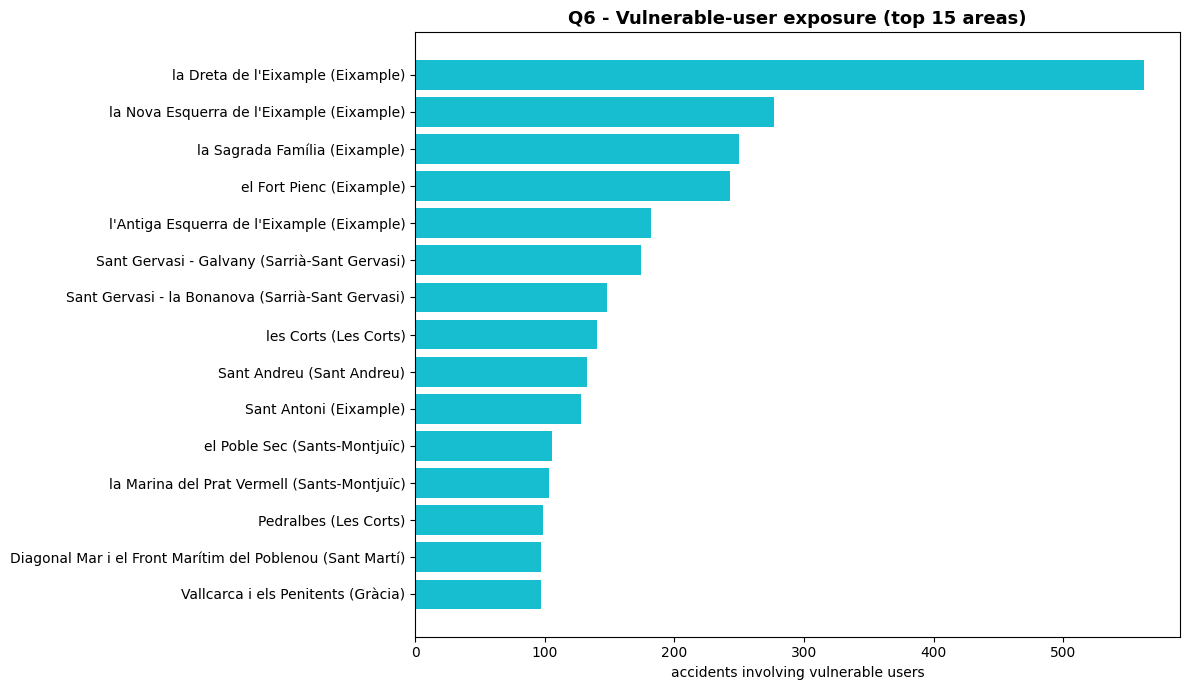

In [23]:
gg = (q6.groupby(["distrito", "barrio"], dropna=False)["numAccidentes"]
        .sum().sort_values(ascending=False).head(15))
labels = [f"{b} ({d})" for (d, b) in gg.index][::-1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(labels, gg.values[::-1], color="#17becf")
ax.set_xlabel("accidents involving vulnerable users")
ax.set_title("Q6 - Vulnerable-user exposure (top 15 areas)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.** Vulnerable-user accidents concentrate in the dense central
districts (Eixample and the old town), where pedestrian and motorbike traffic is highest.
This is the kind of *where-are-people-most-at-risk* question a graph answers cleanly by
walking `Persona →(vehicle filter)→ Accidente → Lugar → barrio` in one pattern.

## Q7 — Daily accidents vs. weather (cross-subgraph bridge)

**Goal — RESEARCH question (analytics).** *Does daily weather correlate with the number of
accidents?* This is the **cross-subgraph** question — and the reason it is **split into two
queries**. Because the accident and weather subgraphs **share no edge**, and because rdflib
mis-joins aggregating sub-SELECTs that share a BIND-computed key (and a flat accident×reading
cross-product ~25M rows *hangs* rdflib), we run **two single-subgraph aggregations**:

- **Q7a** — accidents per calendar day (accident subgraph; typed via `AccidentID` so the
  shared `FechadoEn` predicate doesn't also match weather readings).
- **Q7b** — mean daily value of PPT / TM / VVX10 per station (weather subgraph).

…and **join them on the date string in pandas**. This is the safe, correct, fast pattern.

In [24]:
print('--- Q7a ---'); show_sparql('Q7a_accidents_daily')
print('--- Q7b ---'); show_sparql('Q7b_weather_daily')

--- Q7a ---
# Q7a — Accidents per calendar day (accident subgraph; pure single-pattern aggregation)
# One half of the weather<->accident bridge. Kept as a single-subgraph GROUP BY (no join,
# no cross-product) so the rdflib fallback evaluates it correctly and fast. The date join
# with the weather half (Q7b) is done at visualization time on the ?fecha column.
# ?acc is constrained by AccidentID so the shared FechadoEn predicate does not also match
# weather readings.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?fecha (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc wp:RiUMyEG1nwNphv16JMNmsZ ?accId ;        # AccidentID
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?af .          # FechadoEn (accident)
  BIND(SUBSTR(STR(?af), 1, 10) AS ?fecha)
}
GROUP BY ?fecha
ORDER BY ?fecha

--- Q7b ---
# Q7b — Daily weather readings per station/measure (weather subgraph; single-pattern agg)
# Other half of the bridge. Pure single-subgraph aggregation over the weather readings
# (precipitation PP

In [25]:
q7a = numify(run_query("Q7a_accidents_daily"), ["numAccidentes"])
q7b = numify(run_query("Q7b_weather_daily"), ["valorMedio"])
print(f"Q7a {len(q7a)} days ({QUERY_TIMES['Q7a_accidents_daily']:.2f}s) | "
      f"Q7b {len(q7b)} rows ({QUERY_TIMES['Q7b_weather_daily']:.2f}s)")
merged = q7b.merge(q7a, on="fecha", how="inner")   # the bridge: joined on the DATE in pandas
print(f"joined on date -> {len(merged)} (date,station,measure) rows")
merged.head(8)

Q7a 365 days (0.52s) | Q7b 3283 rows (2.52s)
joined on date -> 3283 (date,station,measure) rows


,fecha,estacion,acronimo,valorMedio,numAccidentes
0,2025-01-01,D5,PPT,0.0,10
1,2025-01-01,D5,TM,8.8,10
2,2025-01-01,D5,VVX10,7.1,10
3,2025-01-01,X4,PPT,0.0,10
4,2025-01-01,X4,TM,11.3,10
5,2025-01-01,X4,VVX10,4.5,10
6,2025-01-01,X8,PPT,0.0,10
7,2025-01-01,X8,TM,10.2,10


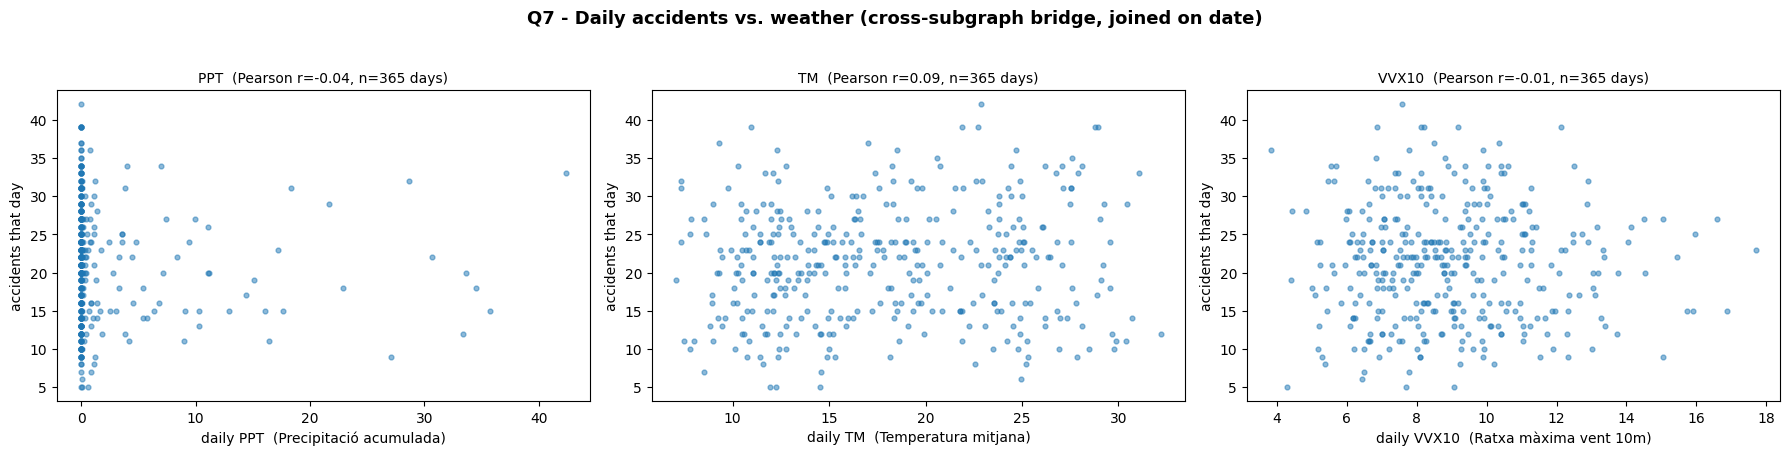

In [26]:
measures = [m for m in ["PPT", "TM", "VVX10"] if m in set(merged["acronimo"])]
fig, axes = plt.subplots(1, len(measures), figsize=(6 * len(measures), 4.6), squeeze=False)
for ax, m in zip(axes[0], measures):
    sub = (merged[merged["acronimo"] == m].groupby("fecha")
           .agg(v=("valorMedio", "mean"), n=("numAccidentes", "first")).dropna())
    ax.scatter(sub["v"], sub["n"], s=12, alpha=0.5)
    corr = sub["v"].corr(sub["n"]) if len(sub) > 2 else float("nan")
    ax.set_title(f"{m}  (Pearson r={corr:.2f}, n={len(sub)} days)", fontsize=10)
    ax.set_xlabel(f"daily {m}  ({O.MEASURE_CODES.get(m, m)})"); ax.set_ylabel("accidents that day")
fig.suptitle("Q7 - Daily accidents vs. weather (cross-subgraph bridge, joined on date)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

**Interpretation.** All three measures show **near-zero Pearson correlation** with
the daily accident count — precipitation (PPT), mean temperature (TM) and max wind gust
(VVX10) do **not** linearly predict how many accidents happen that day at this aggregation.
The analytical *value* here is methodological: we bridged two subgraphs that share no edge,
purely on the date dimension, by composing two safe single-subgraph SPARQL aggregations
with a pandas join — exactly the design the `.rq` headers prescribe.

## 3. Technical report

### 3.1 Execution backends (auto-select)
The pipeline supports two interchangeable SPARQL backends, auto-selected at runtime:
- **GraphDB (recommended)** — a scalable HTTP SPARQL endpoint (`repositories/bcn_meteo`);
  preferred for large graphs and concurrent querying.
- **rdflib in-memory (fallback)** — loads the TTL into a single `rdflib.Graph` and serves
  the identical SPARQL locally; **no server required**, fully self-contained. The backend
  actually used by this run is printed by the setup cell (`BACKEND`) and in the summary
  cell below.

### 3.2 The four rdflib gotchas — and how each query is designed around them
1. **`IN` uses RDF term equality.** A bare `?acronimo IN ("PPT", ...)` compares against the
   plain string `"PPT"`, which does **not** equal the `"PPT"^^xsd:string` literals in the
   ABOX → **0 rows**. **Fix (Q7b):** wrap as `STR(?acronimo) IN ("PPT","TM","VVX10")` so
   both sides normalise to plain strings.
2. **Mis-joined aggregating sub-SELECTs.** rdflib cross-joins two aggregating sub-SELECTs
   that share only a `BIND`-computed key (e.g. a date) instead of joining on it → wrong
   aggregates. **Fix (Q7):** never do the weather↔accident bridge in one SPARQL query;
   compute **Q7a** and **Q7b** independently and join on `?fecha` in pandas.
3. **`FechadoEn` is shared by both subgraphs.** The same predicate dates *both* accidents
   and readings. **Fix (Q7a):** type the accident pattern via `AccidentID`
   (`?acc wp:…AccidentID ?accId`) so the date pattern cannot accidentally match weather
   readings.
4. **Flat cross-products hang rdflib.** A single flat-BGP accident×reading join is
   ~7,741 × ~16,000 ≈ **25M** intermediate rows and hangs. **Fix:** it is never written;
   the graph is loaded **once** and every query is a bounded single- or two-hop pattern.

### 3.3 The Q7-split rationale
Q7 is the only genuinely cross-subgraph question. Because (a) the subgraphs share **no
edge**, (b) gotcha #2 corrupts in-SPARQL date joins, and (c) gotcha #4 makes the naive
cross-product hang, the correct design is **two single-subgraph aggregations joined on the
date in pandas** — fast, correct, and identical in result to what a proper triple-store
join would give.

### 3.4 Date migration: `xsd:string → xsd:dateTimeStamp`
The `FechadoEn` values were recently migrated from `xsd:string` to `xsd:dateTimeStamp`. The
queries extract day/hour with `SUBSTR(STR(?date), …)`, which is **datatype-agnostic** and
remains correct after the migration. Native temporal functions (`HOURS()`, `xsd:dateTime`
casts) **fail on `xsd:dateTimeStamp` in rdflib**, so `SUBSTR(STR())` was kept deliberately
(Q5 hour extraction, Q7a/Q7b day extraction).

### 3.5 Constraints respected
- **Protected files never modified.** `TBOX.owl` and `kg_accidentes_bcn.ttl` are read-only
  teammate-owned artifacts; this notebook only *parses* the TTL.
- **Self-contained TTL.** The TTL embeds the TBOX (with `rdfs:label`s), so class-label
  lookups (Q3/Q5/Q6) work loading **only** the TTL — no separate TBOX import.

### 3.6 Performance notes
- **Load once:** the TTL is parsed a single time (~6–16 s; this run measured below) and the
  resulting `rdflib.Graph` is reused for all eight queries.
- **Per-query times** are recorded in `QUERY_TIMES` and summarised in the next cell.


In [27]:
print(f"Backend used        : {BACKEND}")
print(f"Graph parse time    : {PARSE_SECONDS:.1f}s for {len(g):,} triples")
print(f"Total query time    : {sum(QUERY_TIMES.values()):.2f}s across {len(QUERY_TIMES)} queries\n")
timing = (pd.DataFrame({"query": list(QUERY_TIMES), "seconds": list(QUERY_TIMES.values())})
          .sort_values("seconds", ascending=False).reset_index(drop=True))
timing

Backend used        : rdflib
Graph parse time    : 10.1s for 257,593 triples
Total query time    : 25.19s across 8 queries



,query,seconds
0,Q6_vulnerable_users,7.027338
1,Q3_severity_inconsistency,5.417583
2,Q4_accident_hotspots,2.907960
3,Q2_repeat_coparticipation,2.890983
4,Q5_severity_by_district_hour,2.666054
5,Q7b_weather_daily,2.516053
6,Q1_duplicate_reports,1.245727
7,Q7a_accidents_daily,0.522353


## 4. Conclusion

This pipeline demonstrates what a **graph model** buys for accident-fraud detection and
multi-hop analytics over the Barcelona data:

- **Fraud signals are *structural*.** Q1 (duplicate co-located reports), Q2 (recurring
  demographic fingerprints), and Q3 (label↔count inconsistency) are all **graph motifs** —
  hubs, fan-outs, and contradictions that SPARQL matches directly, returning the *actual
  subgraph* an auditor reviews. Q1 surfaced 19 collision groups, Q2 dense profile clusters
  (up to 7 accidents per fingerprint), and Q3 a clean **0** — a meaningful negative proving
  internal consistency.
- **Multi-hop questions are natural.** Q4–Q6 walk `Persona → Accidente → Lugar → barrio`
  and class-label paths in single patterns to rank hotspots, profile severity by hour, and
  locate vulnerable-user exposure — joins that are implicit in the graph but laborious on
  flat tables.
- **Cross-subgraph reasoning is explicit and safe.** Q7 bridges two edge-disconnected
  subgraphs on the date dimension, finding near-zero weather↔accident correlation, while
  respecting rdflib's evaluation limits by composing two single-subgraph aggregations.

The result is a reproducible, self-contained SPARQL exploitation layer that turns a static
KG into actionable fraud leads and analytical answers — without ever mutating the
teammate-owned schema or instance files.
